## 6월9일(화) 날씨 데이터를 활용한 빅데이터분석 연습(3)

#### -수업을 위한 data  활용을 위해 깃허브 연동하기

In [ ]:
!git clone 'https://'github.com/KangKyungHwa/DSMH/''

fatal: destination path 'DSMH' already exists and is not an empty directory.


In [ ]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache direc

### 4.데이터프레임 편집하기  

####-->깃허브에 저장된 데이터파일을 불러올 때

In [ ]:
import pandas as pd

# [데이터 출처] 기상청, 기상자료개방포털, 종관기상관측(ASOS), https://data.kma.go.kr
df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")
print(df.head(3), '\n\n')
print(df.tail(3))

   지점 지점명          일시  평균기온(°C)  최저기온(°C)  최저기온 시각(hhmi)  최고기온(°C)  \
0  90  속초  2023-01-01       3.2       0.3         2315.0       7.3   
1  90  속초  2023-01-02      -0.5      -5.1          348.0       4.2   
2  90  속초  2023-01-03       0.0      -5.1          754.0       5.6   

   최고기온 시각(hhmi)  일강수량(mm)  평균 풍속(m/s)  평균 상대습도(%)  
0         1346.0       NaN         3.0        21.8  
1         1537.0       NaN         1.4        24.3  
2         1221.0       NaN         1.9        18.3   


        지점 지점명          일시  평균기온(°C)  최저기온(°C)  최저기온 시각(hhmi)  최고기온(°C)  \
34882  295  남해  2023-12-29       3.8       0.3          642.0       8.7   
34883  295  남해  2023-12-30       4.9      -1.1          735.0       9.8   
34884  295  남해  2023-12-31       6.9       2.0         2157.0       9.8   

       최고기온 시각(hhmi)  일강수량(mm)  평균 풍속(m/s)  평균 상대습도(%)  
34882         1518.0       NaN         1.2        66.4  
34883         1501.0       0.9         0.9        81.5  
34884         1104.0       2.1  

####--> *내 pc에서 데이터파일을 불러올 때 처리방법

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

if uploaded:
  # 업로드된 첫 번째 파일의 이름을 가져오기
  fn = list(uploaded.keys())[0]
  print(f'User uploaded file "{fn}"')  # 문자열 안에 변수 값이나 표현식을 쉽게 삽입할 수 있도록 해주는 기능
                                       # 예 : '문자열"{fn}"문자열'  --> 문자열 사이에 변수값을 프린트 해 줌
                                       # {fn} : 선택된 파일이름 보여주기

  try:
    df_uploaded = pd.read_excel(fn)
    print(f'Successfully loaded "{fn}" into a DataFrame.')  # 선택한 파일을 데이터프레임으로 만드는 설명
    #display(df_uploaded.head(2))                            # 상위 3개 데이터 추출
    print(df_uploaded)                                      # 데이터 나타내기
  except Exception as e:
    print(f'Could not read "{fn}" as a CSV file: {e}')      # csv 파일을 선택했을 때 처리 및 멘트
    print('You might need to adjust the reading function based on your file type (e.g., pd.read_excel for Excel files).')
else:
  print("No file was uploaded.")                            # 파일이 없을 때 처리 멘트

Saving ASOS_exam.xlsx to ASOS_exam.xlsx
User uploaded file "ASOS_exam.xlsx"
Successfully loaded "ASOS_exam.xlsx" into a DataFrame.
        지점 지점명          일시  평균기온(°C)  최저기온(°C)  최저기온 시각(hhmi)  최고기온(°C)  \
0       90  속초  2023-01-01       3.2       0.3         2315.0       7.3   
1       90  속초  2023-01-02      -0.5      -5.1          348.0       4.2   
2       90  속초  2023-01-03       0.0      -5.1          754.0       5.6   
3       90  속초  2023-01-04       0.7      -2.7          715.0       5.0   
4       90  속초  2023-01-05       2.5      -1.6            2.0       7.0   
...    ...  ..         ...       ...       ...            ...       ...   
34880  295  남해  2023-12-27       5.4       2.4          406.0      10.8   
34881  295  남해  2023-12-28       5.2       0.2          613.0      13.7   
34882  295  남해  2023-12-29       3.8       0.3          642.0       8.7   
34883  295  남해  2023-12-30       4.9      -1.1          735.0       9.8   
34884  295  남해  2023-12-31       6.9       2

### -데이터 타입 변경: astype (pandas 메서드)

In [ ]:

df['일시'] = df['일시'].astype('datetime64[ns]')
df = df.astype({'지점':'category', '지점명':'category'})
df[['지점', '지점명']] = df[['지점', '지점명']].astype('category')
print(df.dtypes)

지점                     category
지점명                    category
일시               datetime64[ns]
평균기온(°C)                float64
최저기온(°C)                float64
최저기온 시각(hhmi)           float64
최고기온(°C)                float64
최고기온 시각(hhmi)           float64
일강수량(mm)                float64
평균 풍속(m/s)              float64
평균 상대습도(%)              float64
dtype: object


### -*컬럼과 인덱스 편집(1): split,replace (파이썬 기본 메서드), rename (pandas 메서드)

In [ ]:

new_cols = [ col.split('(')[0].replace(' ', '') for col in df.columns]
  # replace :공백을 없애줌
  # split()을 이용하여  ['평균 기온', '°C)'] 로 구분하고 0번째 조각을 가져옴

new_cols_dict = dict(zip(df.columns, new_cols))   #딕셔너리로 만들기
  # df.columns에 있는 현재 컬럼 이름들을 new_cols에 있는 새로운 컬럼
  # 이름들과 일대일로 짝지어, 데이터프레임의 rename() 메서드에 사용할 딕셔너리 생성
  # 예 : zip(['a', 'b'], [1, 2])는 ('a', 1), ('b', 2)와 같은 짝들을 만듦

print(new_cols_dict, '\n\n')

df = df.rename(columns = new_cols_dict)
  #데이터프레임의 컬럼이름을 변경
print(df.head().round(1))


{'지점': '지점', '지점명': '지점명', '일시': '일시', '평균기온(°C)': '평균기온', '최저기온(°C)': '최저기온', '최저기온 시각(hhmi)': '최저기온시각', '최고기온(°C)': '최고기온', '최고기온 시각(hhmi)': '최고기온시각', '일강수량(mm)': '일강수량', '평균 풍속(m/s)': '평균풍속', '평균 상대습도(%)': '평균상대습도'} 


   지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
3  90  속초 2023-01-04   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1    15.6
4  90  속초 2023-01-05   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2    23.8


###-컬럼과 인덱스편집(2) : set_index, reset_index (pandas 의 DataFrame 메서드들)

In [ ]:
   # 새로운 인덱스로 구성된 딕셔너리 생성

#new_index = [f"{i}번" for i in range(len(df))]
new_index = [f"{i+1}번" for i in range(len(df))] # 인덱스번호를 1번부터 시작하고 싶을 때 활용
   # df 데이터프레임의 첫 번째 행(인덱스 0)부터 마지막 행까지(인덱스 `len(df)-1`)
   # 각 행의 인덱스를 `i` 변수에 할당하면서 반복 작업을 수행

new_index_dict = dict(zip(df.index, new_index))
   # 데이터프레임 df의 기존 인덱스(0, 1, 2, ...)를 새로운 형식의 문자열
   # 인덱스('0번', '1번', '2번', ...)로 매핑하는 딕셔너리를 new_index_dict 변수에 저장


df_idx = df.rename(index = new_index_dict)
   # df 데이터프레임의 기존 인덱스를 새로운 인덱스 값으로
   #변경하여 df_idx라는 새로운 데이터프레임을 생성

print(df_idx.head(3).round(1))
print(df_idx.tail(3).round(1))

    지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
1번  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
2번  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
3번  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
         지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
34883번  295  남해 2023-12-29   3.8   0.3   642.0   8.7  1518.0   NaN   1.2   
34884번  295  남해 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9   
34885번  295  남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   

        평균상대습도  
34883번    66.4  
34884번    81.5  
34885번    71.3  


In [ ]:
#인덱스 초기화 : reset_index()

df_idx1 = df_idx.reset_index(drop=False)
#drop의 인자는 기본으로 False 이므로 써주지 않아도 상관없음

print(df_idx1.head(3).round(1), '\n')

df_idx2 = df_idx.reset_index(drop=True) #기존 인덱스 버리고 새로 형성됨
print(df_idx2.head(3).round(1))

  index  지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
0    1번  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
1    2번  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4   
2    3번  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9   

   평균상대습도  
0    21.8  
1    24.3  
2    18.3   

   지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3


####*reset_index(drop=True) 설정 하지 않는경우 : 기존의 인덱스가 그대로 남게 되며 새로운 컬럼으로 추가됨-->True로 설정해야 기존의 index가 삭제됨

In [ ]:
#set_index : DataFrame의 특정 컬럼(또는 여러 컬럼)을 행 인덱스로 설정하는 데 사용

df = df.set_index('지점')
print(df.head(3).round(1), '\n')
print(df.tail(3).round(1), '\n')
#df.to_excel('gijeum.xlsx', index=False)
df = df.reset_index(drop=False)  #현재 데이터프레임의 데이터 인덱스를 초기화
print(df.head(3).round(1))
#df.to_excel('gijeum_.xlsx', index=False)   #인덱스번호확인할 것

   지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
지점                                                                     
90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3 

    지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
지점                                                                      
295  남해 2023-12-29   3.8   0.3   642.0   8.7  1518.0   NaN   1.2    66.4
295  남해 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9    81.5
295  남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6    71.3 

   지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  90  속초 2023-01-03   0.0  -5.1   754.0   5.6

### -데이터 추가: df['column'], loc   

In [ ]:
add_df = df.copy()
new_data1 = add_df['일시'].dt.month
add_df['월'] = new_data1
print(add_df.tail(3))

        지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
34882  295  남해 2023-12-29   3.8   0.3   642.0   8.7  1518.0   NaN   1.2   
34883  295  남해 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9   
34884  295  남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   

       평균상대습도   월  
34882    66.4  12  
34883    81.5  12  
34884    71.3  12  


In [ ]:
import numpy as np
#np.nan의 사용을 위해 numpy 라이브러리 호출
new_data2 = [90, '속초', np.nan, 3.2, 0.3, 2315.0, 7.3, 1346.0, np.nan, 3.0, 21.8, 1]

add_df.loc[34885, :] = new_data2
print(add_df.tail(3))

        지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
34883  295  남해 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9   
34884  295  남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   
34885   90  속초        NaT   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   

       평균상대습도     월  
34883    81.5  12.0  
34884    71.3  12.0  
34885    21.8   1.0  


In [ ]:
add_df.loc[34886, '지점'] = 295
print(add_df.tail(3))

        지점  지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
34884  295   남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   
34885   90   속초        NaT   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
34886  295  NaN        NaT   NaN   NaN     NaN   NaN     NaN   NaN   NaN   

       평균상대습도     월  
34884    71.3  12.0  
34885    21.8   1.0  
34886     NaN   NaN  


#### --인덱스 34888번으로 지점295의 데이터를 추가하고 자 할 때

In [ ]:
add_df.loc[34888, '지점'] = 295         #34887을 건너뜀
print(add_df.tail(4))

        지점  지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
34884  295   남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   
34885   90   속초        NaT   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
34886  295  NaN        NaT   NaN   NaN     NaN   NaN     NaN   NaN   NaN   
34888  295  NaN        NaT   NaN   NaN     NaN   NaN     NaN   NaN   NaN   

       평균상대습도     월  
34884    71.3  12.0  
34885    21.8   1.0  
34886     NaN   NaN  
34888     NaN   NaN  


####*reset_index 확인

In [ ]:

add_df_reset = add_df.reset_index(drop=False)
print(add_df_reset.head(3).round(1), '\n')

add_df_reset = add_df.reset_index(drop=True)  #기존 인덱스 삭제됨
print(add_df_reset.tail(3).round(1), '\n')

add_df_reset.to_excel('re_index.xlsx', index=False)   #인덱스번호확인할 것


   index  지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
0      0  90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
1      1  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4   
2      2  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9   

   평균상대습도    월  
0    21.8  1.0  
1    24.3  1.0  
2    18.3  1.0   

        지점  지점명  일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도    월
34885   90   속초 NaT   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8  1.0
34886  295  NaN NaT   NaN   NaN     NaN   NaN     NaN   NaN   NaN     NaN  NaN
34887  295  NaN NaT   NaN   NaN     NaN   NaN     NaN   NaN   NaN     NaN  NaN 



### -*데이터 수정: df['column'], loc, map, replace, apply

In [ ]:
correct_df1 = df.copy()
correct_df1['지점'] = '지점수정중'
correct_df1['지점명'] = correct_df1['평균기온']   #평균기온의 자료를 '지점명' 에 입력
print(correct_df1)

          지점  지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
0      지점수정중  3.2 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
1      지점수정중 -0.5 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4   
2      지점수정중  0.0 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9   
3      지점수정중  0.7 2023-01-04   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1   
4      지점수정중  2.5 2023-01-05   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2   
...      ...  ...        ...   ...   ...     ...   ...     ...   ...   ...   
34880  지점수정중  5.4 2023-12-27   5.4   2.4   406.0  10.8  1539.0   NaN   0.9   
34881  지점수정중  5.2 2023-12-28   5.2   0.2   613.0  13.7  1415.0   NaN   1.5   
34882  지점수정중  3.8 2023-12-29   3.8   0.3   642.0   8.7  1518.0   NaN   1.2   
34883  지점수정중  4.9 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9   
34884  지점수정중  6.9 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   

       평균상대습도  
0        21.8  
1        24.3  
2        18.3  

In [ ]:
# loc() 예
correct_df1 = df.copy()
correct_df1.loc[0, :] = [90, '속초', np.nan, 4, 5, 6, 7, 8, 9, 10, 11]
print(correct_df1.head(3))

   지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0  90  속초        NaT   4.0   5.0     6.0   7.0     8.0   9.0  10.0    11.0
1  90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3


####*날짜 표현방식을 바꿔보기
####*map() : 파이썬의 내장 함수, 판다스(Pandas) Series 객체에서 사용할 수 있는 메서드
####*lambda()함수 활용 : anonymous fundtion(익명함수)-->주로 한 번 사용되고 버려지는 간단한 함수 만들때 사용

In [ ]:
correct_df2 = df.copy()
correct_df2['일시'] = correct_df2['일시'].map(lambda x: x.strftime("%y%m%d"))
# strftime("%y%m%d") : 원하는 형식의 문자열로 포맷(format)해주는 파이썬의 표준 기능
# map() : 특정 값을 다른 값으로 바꾸고 싶을 때 사용
# 특정 코드 값을 설명하는 문자열로 바꾸는 경우등
print(correct_df2)

        지점 지점명      일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0       90  속초  230101   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1       90  속초  230102  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2       90  속초  230103   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
3       90  속초  230104   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1    15.6
4       90  속초  230105   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2    23.8
...    ...  ..     ...   ...   ...     ...   ...     ...   ...   ...     ...
34880  295  남해  231227   5.4   2.4   406.0  10.8  1539.0   NaN   0.9    61.5
34881  295  남해  231228   5.2   0.2   613.0  13.7  1415.0   NaN   1.5    68.6
34882  295  남해  231229   3.8   0.3   642.0   8.7  1518.0   NaN   1.2    66.4
34883  295  남해  231230   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9    81.5
34884  295  남해  231231   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6    71.3

[34885 rows x 11 columns]


In [ ]:
nunique = correct_df2['지점'].nunique()
point_dict = dict(zip(correct_df2['지점'].unique(), [i for i in range(nunique)]))
correct_df2['지점'] = correct_df2['지점'].map(point_dict)
print(correct_df2)

       지점 지점명      일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0       0  속초  230101   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1       0  속초  230102  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2       0  속초  230103   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
3       0  속초  230104   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1    15.6
4       0  속초  230105   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2    23.8
...    ..  ..     ...   ...   ...     ...   ...     ...   ...   ...     ...
34880  95  남해  231227   5.4   2.4   406.0  10.8  1539.0   NaN   0.9    61.5
34881  95  남해  231228   5.2   0.2   613.0  13.7  1415.0   NaN   1.5    68.6
34882  95  남해  231229   3.8   0.3   642.0   8.7  1518.0   NaN   1.2    66.4
34883  95  남해  231230   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9    81.5
34884  95  남해  231231   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6    71.3

[34885 rows x 11 columns]


In [ ]:
# replace()사용 예
# Pandas DataFrame이나 Series에서 특정 값을 다른 값으로 대체할 때 사용

correct_df3 = df.copy()
correct_df3 = correct_df3.replace({'속초':'SC', np.nan:'00'})
print(correct_df3)

        지점 지점명         일시 평균기온 최저기온  최저기온시각  최고기온  최고기온시각 일강수량 평균풍속 평균상대습도
0       90  SC 2023-01-01  3.2  0.3  2315.0   7.3  1346.0   00  3.0   21.8
1       90  SC 2023-01-02 -0.5 -5.1   348.0   4.2  1537.0   00  1.4   24.3
2       90  SC 2023-01-03  0.0 -5.1   754.0   5.6  1221.0   00  1.9   18.3
3       90  SC 2023-01-04  0.7 -2.7   715.0   5.0  1300.0   00  2.1   15.6
4       90  SC 2023-01-05  2.5 -1.6     2.0   7.0  1424.0   00  2.2   23.8
...    ...  ..        ...  ...  ...     ...   ...     ...  ...  ...    ...
34880  295  남해 2023-12-27  5.4  2.4   406.0  10.8  1539.0   00  0.9   61.5
34881  295  남해 2023-12-28  5.2  0.2   613.0  13.7  1415.0   00  1.5   68.6
34882  295  남해 2023-12-29  3.8  0.3   642.0   8.7  1518.0   00  1.2   66.4
34883  295  남해 2023-12-30  4.9 -1.1   735.0   9.8  1501.0  0.9  0.9   81.5
34884  295  남해 2023-12-31  6.9  2.0  2157.0   9.8  1104.0  2.1  2.6   71.3

[34885 rows x 11 columns]


/tmp/ipykernel_3044/377075074.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  correct_df3 = correct_df3.replace({'속초':'SC', np.nan:'00'})


In [ ]:
# apply() 사용 예
# Pandas DataFrame이나 Series의 데이터를 변형하거나
# 특정 함수를 적용할 때 매우 유용하게 사용

correct_df4 = df.copy()
correct_df4['최저기온시각'] = correct_df4['최저기온시각'].apply(lambda x: str(x)[:-2])
# 최저기온시각의 표시 변형
correct_df4['최저기온시각'] = correct_df4['최저기온시각'].apply(lambda x: f"000{x}" if len(x) ==1 else x)
correct_df4['최저기온시각'] = correct_df4['최저기온시각'].apply(lambda x: f"00{x}" if len(x) ==2 else x)
correct_df4['최저기온시각'] = correct_df4['최저기온시각'].apply(lambda x: f"0{x}" if len(x) ==3 else x)
correct_df4['최저기온시각'] = correct_df4['최저기온시각'].apply(lambda x: f"{x[:2]}:{x[2:]}")

print(correct_df4.filter(['최저기온시각']).head(5))
print(df.filter(['최저기온시각']).head(5))

  최저기온시각
0  23:15
1  03:48
2  07:54
3  07:15
4  00:02
   최저기온시각
0  2315.0
1   348.0
2   754.0
3   715.0
4     2.0


### -*데이터 삭제: drop, dropna, drop_duplicates

In [ ]:
drop_df1 = df.copy()
drop_df1.drop(columns='지점', axis=1, inplace=True)
print(drop_df1.head(), '\n')

drop_df1.drop(index=0, axis=0, inplace=True)
print(drop_df1.head())

  지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
0  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0    21.8
1  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
3  속초 2023-01-04   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1    15.6
4  속초 2023-01-05   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2    23.8 

  지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  평균상대습도
1  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4    24.3
2  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9    18.3
3  속초 2023-01-04   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1    15.6
4  속초 2023-01-05   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2    23.8
5  속초 2023-01-06   3.5  -1.4   224.0   8.4  1333.0   NaN   1.6    36.4


In [ ]:
drop_df2 = df.copy()
drop_df2.dropna(axis=1, inplace=True)
print(drop_df2, '\n')

drop_df3 = df.copy()
drop_df3.dropna(axis=0, inplace=True)
print(drop_df3, '\n')

        지점 지점명         일시
0       90  속초 2023-01-01
1       90  속초 2023-01-02
2       90  속초 2023-01-03
3       90  속초 2023-01-04
4       90  속초 2023-01-05
...    ...  ..        ...
34880  295  남해 2023-12-27
34881  295  남해 2023-12-28
34882  295  남해 2023-12-29
34883  295  남해 2023-12-30
34884  295  남해 2023-12-31

[34885 rows x 3 columns] 

        지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
6       90  속초 2023-01-07   2.5   0.0  2331.0   6.7  1235.0   3.0   1.7   
12      90  속초 2023-01-13   6.1   4.1   819.0   9.0   314.0  14.5   1.5   
13      90  속초 2023-01-14   3.8   0.0  1941.0   7.0    25.0  29.5   3.0   
14      90  속초 2023-01-15  -0.2  -2.0  2315.0   1.8     1.0  47.7   1.3   
15      90  속초 2023-01-16  -2.6  -6.8  2158.0   1.1  1414.0   0.0   1.4   
...    ...  ..        ...   ...   ...     ...   ...     ...   ...   ...   
34868  295  남해 2023-12-15  13.3   9.2  2400.0  18.8  1039.0   1.8   2.8   
34869  295  남해 2023-12-16   3.4  -1.1  2342.0   9.4    26.0 

In [ ]:
drop_df4 = df.copy()
drop_df4.drop_duplicates(inplace=True)
print(drop_df4)

        지점 지점명         일시  평균기온  최저기온  최저기온시각  최고기온  최고기온시각  일강수량  평균풍속  \
0       90  속초 2023-01-01   3.2   0.3  2315.0   7.3  1346.0   NaN   3.0   
1       90  속초 2023-01-02  -0.5  -5.1   348.0   4.2  1537.0   NaN   1.4   
2       90  속초 2023-01-03   0.0  -5.1   754.0   5.6  1221.0   NaN   1.9   
3       90  속초 2023-01-04   0.7  -2.7   715.0   5.0  1300.0   NaN   2.1   
4       90  속초 2023-01-05   2.5  -1.6     2.0   7.0  1424.0   NaN   2.2   
...    ...  ..        ...   ...   ...     ...   ...     ...   ...   ...   
34880  295  남해 2023-12-27   5.4   2.4   406.0  10.8  1539.0   NaN   0.9   
34881  295  남해 2023-12-28   5.2   0.2   613.0  13.7  1415.0   NaN   1.5   
34882  295  남해 2023-12-29   3.8   0.3   642.0   8.7  1518.0   NaN   1.2   
34883  295  남해 2023-12-30   4.9  -1.1   735.0   9.8  1501.0   0.9   0.9   
34884  295  남해 2023-12-31   6.9   2.0  2157.0   9.8  1104.0   2.1   2.6   

       평균상대습도  
0        21.8  
1        24.3  
2        18.3  
3        15.6  
4        23.8  
...

### 5.데이터프레임 재구조화

In [ ]:
import pandas as pd
# [데이터 출처] 기상청, 기상자료개방포털, 종관기상관측(ASOS)
df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")

new_cols = [ col.split('(')[0].replace(' ', '') for col in df.columns]
new_cols_dict = dict(zip(df.columns, new_cols))
df = df.rename(columns = new_cols_dict)
df['일시'] = df['일시'].astype('datetime64[ns]')
df['월'] = df['일시'].dt.month
df['요일'] = df['일시'].dt.weekday
df = df.filter(['지점명', '일시', '월', '요일', '평균기온', '일강수량', '평균풍속', '상대습도'])
print(df)

      지점명         일시   월  요일  평균기온  일강수량  평균풍속
0      속초 2023-01-01   1   6   3.2   NaN   3.0
1      속초 2023-01-02   1   0  -0.5   NaN   1.4
2      속초 2023-01-03   1   1   0.0   NaN   1.9
3      속초 2023-01-04   1   2   0.7   NaN   2.1
4      속초 2023-01-05   1   3   2.5   NaN   2.2
...    ..        ...  ..  ..   ...   ...   ...
34880  남해 2023-12-27  12   2   5.4   NaN   0.9
34881  남해 2023-12-28  12   3   5.2   NaN   1.5
34882  남해 2023-12-29  12   4   3.8   NaN   1.2
34883  남해 2023-12-30  12   5   4.9   0.9   0.9
34884  남해 2023-12-31  12   6   6.9   2.1   2.6

[34885 rows x 7 columns]


### -행열 전환: T

In [ ]:
print(df.head(100).T)

                       0                    1                    2   \
지점명                    속초                   속초                   속초   
일시    2023-01-01 00:00:00  2023-01-02 00:00:00  2023-01-03 00:00:00   
월                       1                    1                    1   
요일                      6                    0                    1   
평균기온                  3.2                 -0.5                  0.0   
일강수량                  NaN                  NaN                  NaN   
평균풍속                  3.0                  1.4                  1.9   

                       3                    4                    5   \
지점명                    속초                   속초                   속초   
일시    2023-01-04 00:00:00  2023-01-05 00:00:00  2023-01-06 00:00:00   
월                       1                    1                    1   
요일                      2                    3                    4   
평균기온                  0.7                  2.5                  3.5   
일강수량 

### -*범주형 변수를 기준으로 집계: groupby

In [ ]:

print(df.groupby(['월', '요일'])[['평균기온', '일강수량', '평균풍속']].mean().round(1), "\n")
print(df.groupby('월')[['요일', '평균기온', '일강수량', '평균풍속']].agg(['mean', 'min', 'max']).round(1))



       평균기온  일강수량  평균풍속
월  요일                  
1  0    0.3   0.5   2.3
   1   -2.0   2.4   2.4
   2   -2.0   0.4   1.6
   3    0.5   1.0   1.3
   4    1.7  11.9   2.5
...     ...   ...   ...
12 2    3.4   1.8   1.9
   3    2.7  16.8   2.2
   4    2.6  18.4   2.2
   5    2.7   2.0   2.1
   6    2.5   2.6   2.0

[84 rows x 3 columns] 

     요일          평균기온              일강수량             평균풍속           
   mean min max  mean   min   max  mean  min    max mean  min   max
월                                                                  
1   2.9   0   6  -0.1 -17.8  17.3   4.5  0.0  108.9  2.0  0.0  19.3
2   3.0   0   6   2.8  -9.3  14.4   2.8  0.0   39.1  1.8  0.0  14.0
3   3.0   0   6   9.5  -2.9  20.6   5.3  0.0   63.4  1.9  0.2  12.2
4   3.2   0   6  13.2   3.6  23.6   5.9  0.0  130.4  2.2  0.1  13.2
5   2.8   0   6  17.9   5.1  30.1  16.3  0.0  287.8  1.9  0.2  13.1
6   3.0   0   6  22.3  13.4  29.2  14.6  0.0  162.1  1.8  0.3   9.2
7   3.1   0   6  25.5  17.4  31.7  24.2  0.0  372.8

In [ ]:
#위의 data를 엑셀파일로 저장해 보기

group_month_daily = df.groupby(['월', '요일'])[['평균기온', '일강수량', '평균풍속']].mean().round(1)
print(group_month_daily, "\n")
group_month_daily.to_excel('mon_daily_mean.xlsx')

print(df.groupby('월')[['요일', '평균기온', '일강수량', '평균풍속']].agg(['mean', 'min', 'max']).round(1))



       평균기온  일강수량  평균풍속
월  요일                  
1  0    0.3   0.5   2.3
   1   -2.0   2.4   2.4
   2   -2.0   0.4   1.6
   3    0.5   1.0   1.3
   4    1.7  11.9   2.5
...     ...   ...   ...
12 2    3.4   1.8   1.9
   3    2.7  16.8   2.2
   4    2.6  18.4   2.2
   5    2.7   2.0   2.1
   6    2.5   2.6   2.0

[84 rows x 3 columns] 

     요일          평균기온              일강수량             평균풍속           
   mean min max  mean   min   max  mean  min    max mean  min   max
월                                                                  
1   2.9   0   6  -0.1 -17.8  17.3   4.5  0.0  108.9  2.0  0.0  19.3
2   3.0   0   6   2.8  -9.3  14.4   2.8  0.0   39.1  1.8  0.0  14.0
3   3.0   0   6   9.5  -2.9  20.6   5.3  0.0   63.4  1.9  0.2  12.2
4   3.2   0   6  13.2   3.6  23.6   5.9  0.0  130.4  2.2  0.1  13.2
5   2.8   0   6  17.9   5.1  30.1  16.3  0.0  287.8  1.9  0.2  13.1
6   3.0   0   6  22.3  13.4  29.2  14.6  0.0  162.1  1.8  0.3   9.2
7   3.1   0   6  25.5  17.4  31.7  24.2  0.0  372.8

### -*날짜/시간 변수를 기준으로 집계: resample  -> 시계열 데이터의 시간 간격을 변경하고 데이터를 집계할 때 사용

In [ ]:
# resample() : 사용할 때는 먼저 '일시' 변수를 인덱스로 설정한 후 사용

resample_df = df.set_index('일시')
print(resample_df)

           지점명   월  요일  평균기온  일강수량  평균풍속
일시                                      
2023-01-01  속초   1   6   3.2   NaN   3.0
2023-01-02  속초   1   0  -0.5   NaN   1.4
2023-01-03  속초   1   1   0.0   NaN   1.9
2023-01-04  속초   1   2   0.7   NaN   2.1
2023-01-05  속초   1   3   2.5   NaN   2.2
...         ..  ..  ..   ...   ...   ...
2023-12-27  남해  12   2   5.4   NaN   0.9
2023-12-28  남해  12   3   5.2   NaN   1.5
2023-12-29  남해  12   4   3.8   NaN   1.2
2023-12-30  남해  12   5   4.9   0.9   0.9
2023-12-31  남해  12   6   6.9   2.1   2.6

[34885 rows x 6 columns]


In [ ]:
# resample() 의 파라메터 --> s : 분, min : 분,  D : 일,  W : 주,  M : 월,  Q : 분기

print(resample_df.resample(rule='3M').max(), '\n')
print(resample_df.resample(rule='Q').count())

            지점명   월  요일  평균기온   일강수량  평균풍속
일시                                        
2023-01-31  흑산도   1   6  17.3  108.9  19.3
2023-04-30  흑산도   4   6  23.6  130.4  14.0
2023-07-31  흑산도   7   6  31.7  372.8  13.1
2023-10-31  흑산도  10   6  33.4  368.7  14.2
2024-01-31  흑산도  12   6  24.3   94.4  20.9 

             지점명     월    요일  평균기온  일강수량  평균풍속
일시                                            
2023-03-31  8542  8542  8542  8539  2138  8525
2023-06-30  8694  8694  8694  8682  3639  8692
2023-09-30  8817  8817  8817  8805  4658  8787
2023-12-31  8832  8832  8832  8822  3059  8820


/tmp/ipykernel_3044/1781501398.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(resample_df.resample(rule='3M').max(), '\n')
/tmp/ipykernel_3044/1781501398.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  print(resample_df.resample(rule='Q').count())


### -열과 행에 새로운 변수를 지정하여 집계 (1): pivot_table -->DataFrame의 변수명으로 데이터를 재구조화함

In [ ]:
# 지점명, 월 의 조합이 중복되는 "평균기온" 데이터의 mean 값을 나타냄
print(df.pivot_table(index='지점명', columns='월', values='평균기온', aggfunc='mean').round(2))

월      1     2      3      4      5      6      7      8      9      10  \
지점명                                                                       
강릉   2.41  5.19  12.07  15.26  20.29  23.15  27.45  26.21  22.40  16.97   
강진군  1.77  4.00  10.03  13.54  18.32  22.87  26.08  27.64  24.14  16.38   
강화  -3.08  0.40   7.07  11.78  16.69  20.86  24.75  25.15  21.90  14.28   
거제   3.09  5.81  11.38  14.18  17.68  22.15  25.23  27.15  23.61  16.59   
거창  -0.92  2.23   9.11  12.51  17.29  22.10  24.91  25.74  21.42  12.79   
..    ...   ...    ...    ...    ...    ...    ...    ...    ...    ...   
합천  -0.10  3.44  10.54  14.00  18.44  23.17  25.78  27.02  23.10  15.15   
해남   1.67  3.24   9.19  13.22  18.01  22.34  26.01  26.94  23.68  15.88   
홍성  -1.12  1.51   8.48  13.08  18.51  22.82  26.02  26.55  22.74  15.18   
홍천  -4.40  0.21   8.03  12.35  17.72  22.31  25.46  25.70  21.53  12.30   
흑산도  4.22  4.40   8.28  11.76  15.56  19.85  23.06  25.48  22.73  17.69   

월       11    12  
지점명  

In [ ]:
print(df.pivot_table(index=['지점명', '요일'], columns=['월'], values='평균기온', aggfunc='max').round(2))

### -열과 행에 새로운 변수를 지정하여 집계 (2): crosstab --> pivot_table()과 비슷한 기능 --> 배열이나 시리즈, 리스트 형태의 데이터를 입력하여 교차표 생성


In [ ]:
from pandas import crosstab
print(crosstab(index=df['지점명'], columns=df['월'], values=df['평균기온'], aggfunc='mean').round(2))

In [ ]:
print(crosstab(index=[df['지점명'], df['요일']], columns=df['월'], values=df['평균기온'], aggfunc='max').round(2))

### -*melt(): 변수와 값을 기준으로 재구조화:   여러 열에 걸쳐 있는 값들을 하나의 열로 모으고, 원래 열 이름들은 다른 새 열에 저장

In [ ]:
df_melt = df.melt()
print(df_melt, "\n")

print(list(df.columns))
print(df_melt['variable'].unique())

       variable value
0           지점명    속초
1           지점명    속초
2           지점명    속초
3           지점명    속초
4           지점명    속초
...         ...   ...
244190     평균풍속   0.9
244191     평균풍속   1.5
244192     평균풍속   1.2
244193     평균풍속   0.9
244194     평균풍속   2.6

[244195 rows x 2 columns] 

['지점명', '일시', '월', '요일', '평균기온', '일강수량', '평균풍속']
['지점명' '일시' '월' '요일' '평균기온' '일강수량' '평균풍속']


In [ ]:
df_melt1 = df.melt(id_vars=['지점명'])
print(df_melt1, "\n")

print(list(df.columns))
print(df_melt1['variable'].unique())

       지점명 variable                value
0       속초       일시  2023-01-01 00:00:00
1       속초       일시  2023-01-02 00:00:00
2       속초       일시  2023-01-03 00:00:00
3       속초       일시  2023-01-04 00:00:00
4       속초       일시  2023-01-05 00:00:00
...     ..      ...                  ...
209305  남해     평균풍속                  0.9
209306  남해     평균풍속                  1.5
209307  남해     평균풍속                  1.2
209308  남해     평균풍속                  0.9
209309  남해     평균풍속                  2.6

[209310 rows x 3 columns] 

['지점명', '일시', '월', '요일', '평균기온', '일강수량', '평균풍속']
['일시' '월' '요일' '평균기온' '일강수량' '평균풍속']


In [ ]:
df_melt2 = df.melt(id_vars=['지점명'], value_vars=['평균기온', '평균풍속'])
print(df_melt2, "\n")

print(list(df.columns))
print(df_melt2['variable'].unique())

### 6.데이터프레임 연결하기: merge, concat

In [ ]:
import pandas as pd
# [데이터 출처] 기상청, 기상자료개방포털, 종관기상관측(ASOS), https://data.kma.go.kr

df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")

new_cols = [ col.split('(')[0].replace(' ', '') for col in df.columns]
new_cols_dict = dict(zip(df.columns, new_cols))
df = df.rename(columns = new_cols_dict)

df['일시'] = df['일시'].astype('datetime64[ns]')
df['날짜'] = df['일시']

df1 = df.filter(['일시', '지점명', '평균기온']).query("일시 <= '2023-05-31'")
df2 = df.filter(['일시', '지점명', '평균풍속'])
df3 = df.filter(['날짜', '지점명', '최고기온'])
df11 = df1.query("일시 <= '2023-05-31'").groupby('일시')['평균기온'].mean()
df33 = df3.query("날짜 > '2023-05-31'").groupby('날짜')['최고기온'].mean()

In [ ]:
print(df1, "\n")
print(df2)

#### *merge()

`merge()` 함수는 하나 이상의 키(key) 컬럼의 값을 기준으로 두 개의 DataFrame을 결합(join)하는 데 사용, SQL의 JOIN 연산과 매우 유사하며, 특정 조건을 만족하는 행들을 합칠 때 유용

주요 매개변수:

*   **`right`**: 병합할 오른쪽 DataFrame.
*   **`how`**: 병합 방식을 지정합니다. SQL의 JOIN 타입과 동일
    *   `'inner'` (기본값): 양쪽 DataFrame에 모두 존재하는 키 값만을 포함 (교집합)
    *   `'left'` : 왼쪽 DataFrame의 모든 키 값을 포함하고, 오른쪽 DataFrame에 일치하는 키가 없으면 `NaN`으로 채움
    *   `'right'` : 오른쪽 DataFrame의 모든 키 값을 포함하고, 왼쪽 DataFrame에 일치하는 키가 없으면 `NaN`으로 채움
    *   `'outer'` : 양쪽 DataFrame의 모든 키 값을 포함하고, 일치하지 않는 부분은 `NaN`으로 채움 (합집합)
*   **`on`**: 키로 사용할 컬럼(또는 컬럼 리스트)의 이름을 지정, 양쪽 DataFrame에 동일한 이름의 키 컬럼이 있을 때 사용
*   **`left_on`**: 왼쪽 DataFrame의 키 컬럼 이름을 지정
*   **`right_on`**: 오른쪽 DataFrame의 키 컬럼 이름을 지정, 양쪽 DataFrame의 키 컬럼 이름이 다를 때 사용
*   **`left_index`**: 왼쪽 DataFrame의 인덱스를 키로 사용할지 여부를 지정, `True`로 설정하면 인덱스를 키로 사용
*   **`right_index`**: 오른쪽 DataFrame의 인덱스를 키로 사용할지 여부를 지정, `True`로 설정하면 인덱스를 키로 사용

In [ ]:
from pandas import merge
print(merge(df1, df2, on=['일시', '지점명'], how='inner'))

              일시 지점명  평균기온  평균풍속
0     2023-01-01  속초   3.2   3.0
1     2023-01-02  속초  -0.5   1.4
2     2023-01-03  속초   0.0   1.9
3     2023-01-04  속초   0.7   2.1
4     2023-01-05  속초   2.5   2.2
...          ...  ..   ...   ...
14361 2023-05-27  남해  21.8   1.6
14362 2023-05-28  남해  21.8   1.9
14363 2023-05-29  남해  22.3   1.5
14364 2023-05-30  남해  19.1   0.7
14365 2023-05-31  남해  20.0   1.7

[14366 rows x 4 columns]


In [ ]:
print(merge(df1, df2, on=['일시', '지점명'], how='right'))

              일시 지점명  평균기온  평균풍속
0     2023-01-01  속초   3.2   3.0
1     2023-01-02  속초  -0.5   1.4
2     2023-01-03  속초   0.0   1.9
3     2023-01-04  속초   0.7   2.1
4     2023-01-05  속초   2.5   2.2
...          ...  ..   ...   ...
34880 2023-12-27  남해   NaN   0.9
34881 2023-12-28  남해   NaN   1.5
34882 2023-12-29  남해   NaN   1.2
34883 2023-12-30  남해   NaN   0.9
34884 2023-12-31  남해   NaN   2.6

[34885 rows x 4 columns]


In [ ]:
print(df2, "\n")
print(df3)

              일시 지점명  평균풍속
0     2023-01-01  속초   3.0
1     2023-01-02  속초   1.4
2     2023-01-03  속초   1.9
3     2023-01-04  속초   2.1
4     2023-01-05  속초   2.2
...          ...  ..   ...
34880 2023-12-27  남해   0.9
34881 2023-12-28  남해   1.5
34882 2023-12-29  남해   1.2
34883 2023-12-30  남해   0.9
34884 2023-12-31  남해   2.6

[34885 rows x 3 columns] 

              날짜 지점명  최고기온
0     2023-01-01  속초   7.3
1     2023-01-02  속초   4.2
2     2023-01-03  속초   5.6
3     2023-01-04  속초   5.0
4     2023-01-05  속초   7.0
...          ...  ..   ...
34880 2023-12-27  남해  10.8
34881 2023-12-28  남해  13.7
34882 2023-12-29  남해   8.7
34883 2023-12-30  남해   9.8
34884 2023-12-31  남해   9.8

[34885 rows x 3 columns]


In [ ]:
print(merge(df2, df3, left_on=['일시', '지점명'], right_on=['날짜', '지점명']))

              일시 지점명  평균풍속         날짜  최고기온
0     2023-01-01  속초   3.0 2023-01-01   7.3
1     2023-01-02  속초   1.4 2023-01-02   4.2
2     2023-01-03  속초   1.9 2023-01-03   5.6
3     2023-01-04  속초   2.1 2023-01-04   5.0
4     2023-01-05  속초   2.2 2023-01-05   7.0
...          ...  ..   ...        ...   ...
34880 2023-12-27  남해   0.9 2023-12-27  10.8
34881 2023-12-28  남해   1.5 2023-12-28  13.7
34882 2023-12-29  남해   1.2 2023-12-29   8.7
34883 2023-12-30  남해   0.9 2023-12-30   9.8
34884 2023-12-31  남해   2.6 2023-12-31   9.8

[34885 rows x 5 columns]


In [ ]:
print(df11, "\n")
print(df33)

일시
2023-01-01     0.957895
2023-01-02    -1.653684
2023-01-03    -2.270526
2023-01-04    -1.078947
2023-01-05    -0.160000
                ...    
2023-05-27    20.611458
2023-05-28    20.275000
2023-05-29    20.586458
2023-05-30    20.201042
2023-05-31    20.351042
Name: 평균기온, Length: 151, dtype: float64 

날짜
2023-06-01    23.240625
2023-06-02    27.062500
2023-06-03    27.207292
2023-06-04    27.766667
2023-06-05    26.131250
                ...    
2023-12-27     9.054167
2023-12-28     8.490625
2023-12-29     7.981250
2023-12-30     7.127083
2023-12-31     7.506250
Name: 최고기온, Length: 214, dtype: float64


In [ ]:
print(merge(df11, df33, left_index=True, right_index=True, how='outer'))

                평균기온      최고기온
2023-01-01  0.957895       NaN
2023-01-02 -1.653684       NaN
2023-01-03 -2.270526       NaN
2023-01-04 -1.078947       NaN
2023-01-05 -0.160000       NaN
...              ...       ...
2023-12-27       NaN  9.054167
2023-12-28       NaN  8.490625
2023-12-29       NaN  7.981250
2023-12-30       NaN  7.127083
2023-12-31       NaN  7.506250

[365 rows x 2 columns]


In [ ]:
df_a = df.query("일시<='2023-05-31' and 지점명=='남해'")[['일시', '최고기온']]
df_b = df.query("일시>'2023-05-31' and 지점명=='남해'")[['일시', '최고기온']]
df_c = df.query("지점명=='남해'")[['최저기온']]

print(df_a, "\n")
print(df_b, "\n")
print(df_c)

              일시  최고기온
34520 2023-01-01   8.9
34521 2023-01-02   6.8
34522 2023-01-03   6.1
34523 2023-01-04   8.1
34524 2023-01-05   7.9
...          ...   ...
34666 2023-05-27  24.7
34667 2023-05-28  23.0
34668 2023-05-29  25.1
34669 2023-05-30  20.4
34670 2023-05-31  25.3

[151 rows x 2 columns] 

              일시  최고기온
34671 2023-06-01  18.2
34672 2023-06-02  30.6
34673 2023-06-03  27.3
34674 2023-06-04  28.2
34675 2023-06-05  26.6
...          ...   ...
34880 2023-12-27  10.8
34881 2023-12-28  13.7
34882 2023-12-29   8.7
34883 2023-12-30   9.8
34884 2023-12-31   9.8

[214 rows x 2 columns] 

       최저기온
34520  -1.3
34521  -3.3
34522  -4.5
34523  -3.4
34524  -2.0
...     ...
34880   2.4
34881   0.2
34882   0.3
34883  -1.1
34884   2.0

[365 rows x 1 columns]


#### *concat()

 함수는 여러 개의 pandas 객체(DataFrame 또는 Series)를 하나의 객체로 결합,    병합(merge)이나 조인(join)과 달리, concat()은 인덱스나 컬럼 값을 기준으로 데이터를 정렬하거나 일치시키려 하지 않고, 주어진 순서대로만 이어 붙임

주요 매개:

*  (예: `[df1, df2, df3]`)
*   **`axis`**: 데이터를 이어 붙일 축 지정
    *   `axis=0` (기본값): 행을 기준으로 데이터를 위아래로 연결
    *   `axis=1`: 열을 기준으로 데이터를 좌우로 연결
*   **`join`**: 다른 축의 인덱스(또는 컬럼)를 어떻게 처리할지 지
    *   `'outer'` (기본값): 모든 인덱스/컬럼을 포함, 일치하지 않는 부분은 `NaN`으로 채움
    *   `'inner'`: 양쪽에 모두 존재하는 인덱스/컬럼만 포함
*   **`ignore_index`**: `True`로 설정하면 기존 인덱스를 무시하고 새롭게 0부터 시작하는 인덱스를 생성

In [ ]:
from pandas import concat
concat_ab = concat([df_a, df_b], axis=0)
print(concat_ab)

              일시  최고기온
34520 2023-01-01   8.9
34521 2023-01-02   6.8
34522 2023-01-03   6.1
34523 2023-01-04   8.1
34524 2023-01-05   7.9
...          ...   ...
34880 2023-12-27  10.8
34881 2023-12-28  13.7
34882 2023-12-29   8.7
34883 2023-12-30   9.8
34884 2023-12-31   9.8

[365 rows x 2 columns]


In [ ]:
print(concat([concat_ab, df_c], axis=1))

              일시  최고기온  최저기온
34520 2023-01-01   8.9  -1.3
34521 2023-01-02   6.8  -3.3
34522 2023-01-03   6.1  -4.5
34523 2023-01-04   8.1  -3.4
34524 2023-01-05   7.9  -2.0
...          ...   ...   ...
34880 2023-12-27  10.8   2.4
34881 2023-12-28  13.7   0.2
34882 2023-12-29   8.7   0.3
34883 2023-12-30   9.8  -1.1
34884 2023-12-31   9.8   2.0

[365 rows x 3 columns]


### 7.데이터프레임과 유용한 메서드들

In [ ]:
from pandas import read_csv
# [데이터 출처] 기상청, 기상자료개방포털, 종관기상관측(ASOS), https://data.kma.go.kr
df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")

new_cols = [ col.split('(')[0].replace(' ', '') for col in df.columns]
                               #replace() 중복된 행 제거
new_cols_dict = dict(zip(df.columns, new_cols))
df = df.rename(columns = new_cols_dict)

df['월'] = df['일시'].astype('datetime64[ns]').dt.month
df = df.query("지점명=='남해'")[['월', '최저기온', '평균상대습도', '평균풍속']]

print(df)

        월  최저기온  평균상대습도  평균풍속
34520   1  -1.3    56.3   2.1
34521   1  -3.3    37.5   1.1
34522   1  -4.5    49.4   1.3
34523   1  -3.4    55.1   1.4
34524   1  -2.0    70.3   0.9
...    ..   ...     ...   ...
34880  12   2.4    61.5   0.9
34881  12   0.2    68.6   1.5
34882  12   0.3    66.4   1.2
34883  12  -1.1    81.5   0.9
34884  12   2.0    71.3   2.6

[365 rows x 4 columns]


### -*범주형 변수의 정보 확인: unique, nunique, value_counts

In [ ]:
print(df['월'].unique()),
print("고유값 월의 개수:",df['월'].nunique(), '\n') # 월의 갯수를 알려줌
print(df['월'].value_counts(), '\n') #각 월의 갯수
print(df['월'].value_counts(normalize=True).round(3))  #각 월의 비율 나타냄

[ 1  2  3  4  5  6  7  8  9 10 11 12]
고유값 월의 개수: 12 

월
1     31
3     31
7     31
5     31
12    31
10    31
8     31
4     30
9     30
6     30
11    30
2     28
Name: count, dtype: int64 

월
1     0.085
3     0.085
7     0.085
5     0.085
12    0.085
10    0.085
8     0.085
4     0.082
9     0.082
6     0.082
11    0.082
2     0.077
Name: proportion, dtype: float64


### -데이터 정렬: sort_values

In [ ]:
print(df.sort_values(by='최저기온', ascending=False))

        월  최저기온  평균상대습도  평균풍속
34754   8  26.3    81.3   NaN
34737   8  25.9    77.9   1.3
34738   8  25.7    76.5   1.2
34753   8  25.6    81.6   NaN
34739   8  25.5    74.9   1.7
...    ..   ...     ...   ...
34545   1  -6.9    55.8   1.0
34547   1  -7.7    47.4   2.4
34875  12  -7.8    53.0   2.0
34543   1  -8.4    37.0   4.8
34544   1 -11.7    36.0   1.4

[365 rows x 4 columns]


### -통계: sum, mean, median, std, var, max, min, mode, cumsum, quantile, rank

In [ ]:
df = df.set_index('월')   #특정 열을 행 index로 바꿈
print("mean\n", df.mean(), '\n')  #평균
print("std\n", df.std(), '\n')    #표준편차
print("max\n", df.max(), '\n')    #최대갓
print("quantile\n", df.quantile(0.75), '\n')
print("rank\n", df.rank())

### -왜도와 첨도: skew, kurtosis

In [ ]:
print('skew\n', df.skew(), "\n")
print('kurtosis\n', df.kurtosis())

skew
 월        -0.010500
최저기온     -0.166602
평균상대습도   -0.311579
평균풍속      1.631168
dtype: float64 

kurtosis
 월        -1.207131
최저기온     -1.158576
평균상대습도   -0.691205
평균풍속      3.631410
dtype: float64


### -왜도와 첨도 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

최저기온의 왜도(Skewness): -0.17
최저기온의 첨도(Kurtosis): -1.16



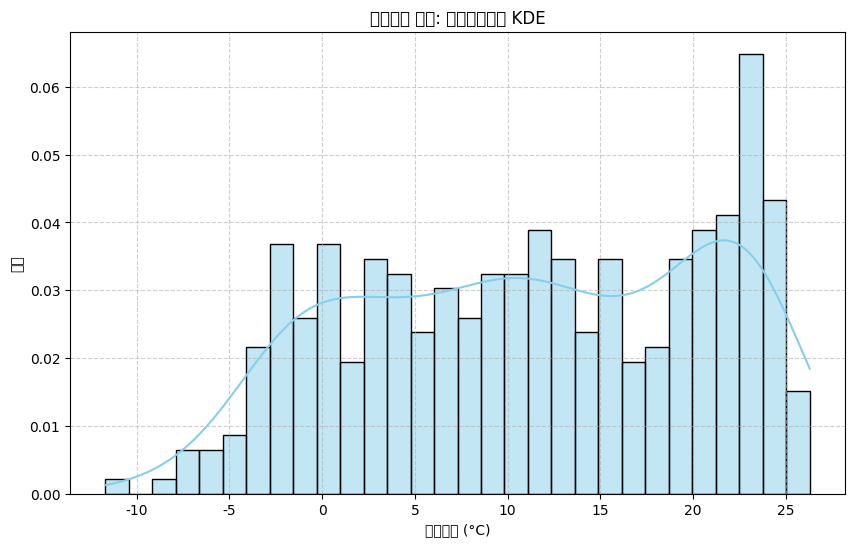

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있지만, 명시적으로 다시 설정)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 'df' DataFrame이 '월'을 인덱스로 가지고 있으므로, 컬럼을 바로 선택
# 시각화를 위해 '최저기온' 컬럼을 선택
# 결측값은 제외하고 시각화하는 것이 일반적
data_to_plot = df['최저기온'].dropna()

# 왜도와 첨도 값 출력 (이전 셀 결과 재확인)
print(f"최저기온의 왜도(Skewness): {data_to_plot.skew():.2f}")
print(f"최저기온의 첨도(Kurtosis): {data_to_plot.kurtosis():.2f}\n")

# 히스토그램과 KDE 플롯 그리기
plt.figure(figsize=(10, 6))
sns.histplot(data_to_plot, kde=True, bins=30, color='skyblue', edgecolor='black', stat='density')
plt.title('최저기온 분포: 히스토그램과 KDE')
plt.xlabel('최저기온 (°C)')
plt.ylabel('밀도')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


*   **왜도 (Skewness):**
    *   ** - 왜도 (왼쪽 꼬리):** 그래프의 꼬리가 왼쪽으로 길게 늘어져 있음,  데이터 대부분 > 평균 집중되어 있음,  `최저기온`의 왜도 값 -0.17 은  분포가 약간 왼쪽으로 치우쳐 있음을 보여줌
    *   ** + 왜도 (오른쪽 꼬리):** 그래프의 꼬리가 오른쪽으로 길게 늘어져 있음 데이터의 대부분 < 평균
    *   **왜도 = 0에 가까움: 분포가 대칭적(정규 분포의 왜도는 0).


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54413 (\N{HANGUL SYLLABLE PUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

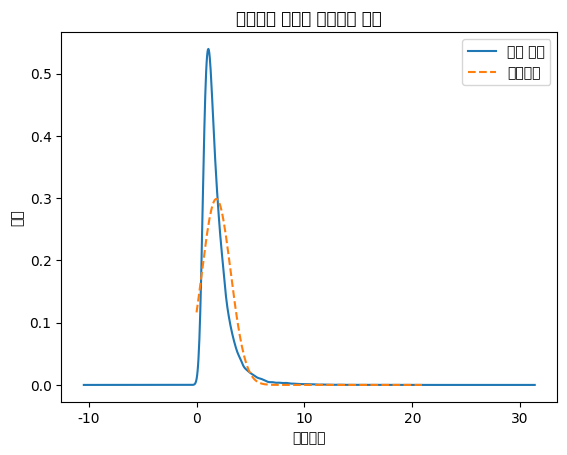

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 한글 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

temp_df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")
new_cols_raw = [ col.split('(')[0].replace(' ', '') for col in temp_df.columns]
new_cols_dict_raw = dict(zip(temp_df.columns, new_cols_raw))
temp_df = temp_df.rename(columns = new_cols_dict_raw)

# 한 칼럼 선택
data = temp_df['평균풍속'].dropna()

# 평균 / 표준편차
mean = data.mean()
std = data.std()

# 실제 데이터 분포 곡선
data.plot(kind='density', label='실제 분포')

# 정규분포 곡선
x = np.linspace(data.min(), data.max(), 200)

y = (1 / (std * np.sqrt(2*np.pi))) * \
    np.exp(-(x-mean)**2 / (2*std**2))

plt.plot(x, y, linestyle='--', label='정규분포')

plt.title('평균풍속 분포와 정규분포 비교')
plt.xlabel('평균풍속')
plt.ylabel('밀도')

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

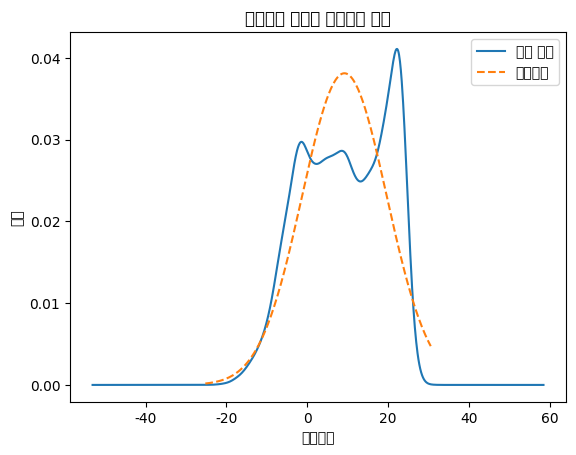

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 한글 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

temp_df = pd.read_csv("DSMH/example_data/sample_8/ASOS_exam.csv")
new_cols_raw = [ col.split('(')[0].replace(' ', '') for col in temp_df.columns]
new_cols_dict_raw = dict(zip(temp_df.columns, new_cols_raw))
temp_df = temp_df.rename(columns = new_cols_dict_raw)

# 한 칼럼 선택
data = temp_df['최저기온'].dropna()

# 평균 / 표준편차
mean = data.mean()
std = data.std()

# 실제 데이터 분포 곡선
data.plot(kind='density', label='실제 분포')

# 정규분포 곡선
x = np.linspace(data.min(), data.max(), 200)

y = (1 / (std * np.sqrt(2*np.pi))) * \
    np.exp(-(x-mean)**2 / (2*std**2))

plt.plot(x, y, linestyle='--', label='정규분포')

plt.title('최저기온 분포와 정규분포 비교')
plt.xlabel('최저기온')
plt.ylabel('밀도')

plt.legend()
plt.show()

### -공분산과 상관계수: cov, corr

In [ ]:
print('cov\n', df.cov(), "\n")
print('corr\n', df.corr(method='pearson'))

cov
                 월        최저기온      평균상대습도      평균풍속
월       11.920337    9.452050   12.828494  0.133634
최저기온     9.452050   86.722067  101.586574 -1.128916
평균상대습도  12.828494  101.586574  258.297584 -3.242020
평균풍속     0.133634   -1.128916   -3.242020  0.437739 

corr
                월      최저기온    평균상대습도      평균풍속
월       1.000000  0.293979  0.231191  0.057775
최저기온    0.293979  1.000000  0.678752 -0.186091
평균상대습도  0.231191  0.678752  1.000000 -0.303989
평균풍속    0.057775 -0.186091 -0.303989  1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'  #그래프의 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# Numerical columns to plot
numeric_cols = ['최저기온', '평균상대습도']

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(18, 6))

# Plot 1: 최저기온 vs 평균상대습도
sns.scatterplot(data=df, x='최저기온', y='평균상대습도', ax=ax)
ax.set_title('최저기온 vs 평균상대습도')
ax.set_xlabel('최저기온')
ax.set_ylabel('평균상대습도')
ax.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()